# Split train / val / test — verificación

Generamos el reparto **estratificado por diagnóstico y agrupado por paciente**, mostramos la
salida y verificamos que las divisiones estén bien hechas:
1. tamaños de cada conjunto,
2. que se mantengan las proporciones de las 6 clases,
3. que **ningún paciente aparezca en más de un conjunto** (chequeo anti-leakage).

Si todo está OK, guardamos `data/splits.csv`.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt

from src.data.dataset import load_dataset
from src.data.split import make_split, patient_overlap, class_distribution

## 1. Generar el split

In [2]:
df = load_dataset()
df = make_split(df, n_splits=7, seed=42)
df["split"].value_counts()

split
train    1640
test      329
val       329
Name: count, dtype: int64

## 2. Tamaños por conjunto

split
train    1640
val       329
test      329
Name: count, dtype: int64
split
train    71.4
val      14.3
test     14.3
Name: count, dtype: float64


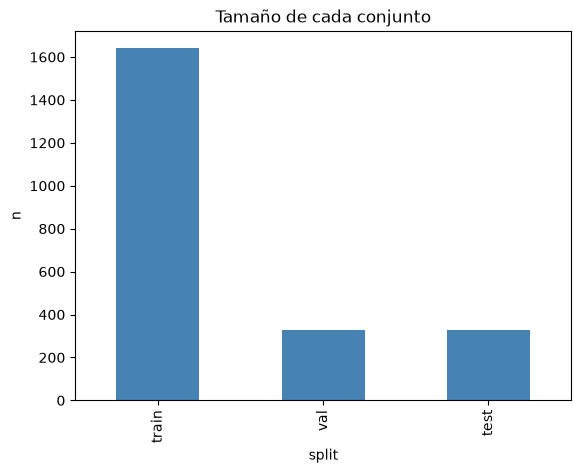

In [3]:
sizes = df["split"].value_counts().reindex(["train", "val", "test"])
print(sizes)
print((sizes / len(df) * 100).round(1))

sizes.plot(kind="bar", color="steelblue", title="Tamaño de cada conjunto")
plt.ylabel("n"); plt.show()

## 3. Distribución de clases por conjunto

La estratificación es **aproximada** (el grano mínimo es el paciente), así que buscamos que las
proporciones sean parecidas entre train/val/test, no idénticas. Ojo con MEL, la clase minoritaria.

In [4]:
counts, props = class_distribution(df)
print("Conteos:"); print(counts.reindex(columns=["train", "val", "test"]))
print("\nProporciones por conjunto:"); print(props.reindex(columns=["train", "val", "test"]))

Conteos:
split       train  val  test
diagnostic                  
ACK           521  105   104
BCC           603  121   121
MEL            37    8     7
NEV           174   35    35
SCC           137   27    28
SEK           168   33    34

Proporciones por conjunto:
split       train    val   test
diagnostic                     
ACK         0.318  0.319  0.316
BCC         0.368  0.368  0.368
MEL         0.023  0.024  0.021
NEV         0.106  0.106  0.106
SCC         0.084  0.082  0.085
SEK         0.102  0.100  0.103


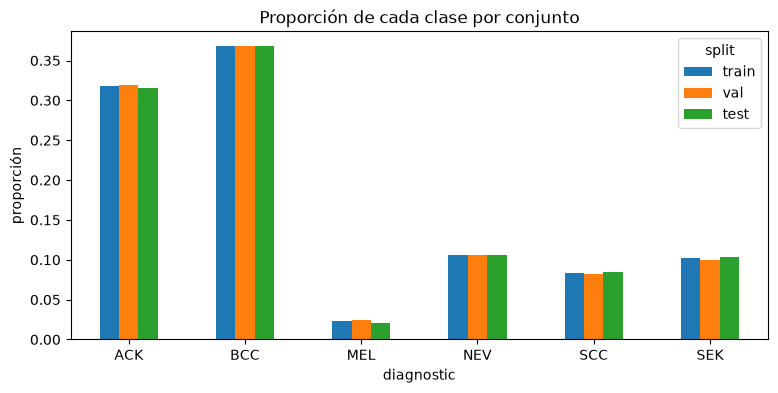

In [5]:
props.reindex(columns=["train", "val", "test"]).plot(
    kind="bar", figsize=(9, 4), title="Proporción de cada clase por conjunto")
plt.ylabel("proporción"); plt.xticks(rotation=0); plt.show()

## 4. Verificación anti-leakage

Ningún `patient_id` debe estar en más de un conjunto. La celda tiene que dar **0 pacientes**
solapados (y el `assert` no debe fallar).

In [6]:
overlap = patient_overlap(df)
print("pacientes en más de un conjunto:", len(overlap))
assert len(overlap) == 0, "LEAKAGE: hay pacientes en varios conjuntos"
print("OK: ningún paciente cruza conjuntos")

pacientes en más de un conjunto: 0
OK: ningún paciente cruza conjuntos


In [7]:
print("pacientes por conjunto:")
print(df.groupby("split")["patient_id"].nunique())
print("\ntotal pacientes:", df["patient_id"].nunique())

pacientes por conjunto:
split
test     197
train    978
val      198
Name: patient_id, dtype: int64

total pacientes: 1373


## 5. Guardar el reparto

Guardamos solo el mapa `img_id -> split` (+ `patient_id` para auditar). Es liviano y se versiona
en Git para que todos usen exactamente el mismo reparto.

In [8]:
out = df[["img_id", "patient_id", "diagnostic", "split"]]
path = ROOT / "data" / "splits.csv"
out.to_csv(path, index=False)
print("guardado:", path, "|", len(out), "filas")
out.head()

guardado: /Users/alejandrodiaz/Documents/personal/Master ORT/ML en Produccion/data/splits.csv | 2298 filas


,img_id,patient_id,diagnostic,split
0,PAT_1516_1765_530.png,PAT_1516,NEV,test
1,PAT_46_881_939.png,PAT_46,BCC,train
2,PAT_1545_1867_547.png,PAT_1545,ACK,train
3,PAT_1989_4061_934.png,PAT_1989,ACK,train
4,PAT_684_1302_588.png,PAT_684,BCC,test
